In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import download_prices
from src.returns import compute_simple_returns
from src.pairs import compute_return_correlations, get_unique_pairs, rank_pairs_by_correlation

In [3]:
tickers = [
    "SPY", "QQQ", "IWM",
    "XLK", "XLF", "XLE", "XLV",
    "XLY", "XLP", "XLI", "XLU",
    "TLT", "HYG", "LQD", "GLD",
]

prices = download_prices(
    tickers=tickers,
    start="2015-01-01",
    end="2026-01-01",
)

returns = compute_simple_returns(prices)

ranked_pairs = rank_pairs_by_correlation(returns)

print(prices.shape)
print(returns.shape)
print(ranked_pairs.shape)
print(ranked_pairs.head(10))

Loading SPY from cache...
Loading QQQ from cache...
Loading IWM from cache...
Loading XLK from cache...
Loading XLF from cache...
Loading XLE from cache...
Loading XLV from cache...
Loading XLY from cache...
Loading XLP from cache...
Loading XLI from cache...
Loading XLU from cache...
Loading TLT from cache...
Loading HYG from cache...
Loading LQD from cache...
Loading GLD from cache...
(2766, 15)
(2765, 15)
(105, 3)
   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


In [4]:
high_corr_pairs = ranked_pairs[ranked_pairs["correlation"] >= 0.85]

print(high_corr_pairs)
print(high_corr_pairs.shape)

   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
(9, 3)


In [5]:
print(prices.shape)
print(returns.shape)
print(ranked_pairs.shape)
print(ranked_pairs.head(10))

(2766, 15)
(2765, 15)
(105, 3)
   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


In [6]:
ticker_y = "XLK"
ticker_x = "QQQ"

In [7]:
from src.spread import estimate_hedge_ratio, compute_spread

alpha, beta = estimate_hedge_ratio(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
)

spread = compute_spread(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    alpha=alpha,
    beta=beta,
)

print("alpha:", alpha)
print("beta:", beta)
print(spread.head())
print(spread.describe())

alpha: -6.083477534786367
beta: 0.24068529955583914
Date
2015-01-02    1.386741
2015-01-05    1.444847
2015-01-06    1.531087
2015-01-07    1.394679
2015-01-08    1.355285
Name: XLK_QQQ_spread, dtype: float64
count    2.766000e+03
mean    -4.282780e-14
std      2.489940e+00
min     -6.904320e+00
25%     -1.007093e+00
50%      2.242802e-01
75%      1.381208e+00
max      5.553757e+00
Name: XLK_QQQ_spread, dtype: float64


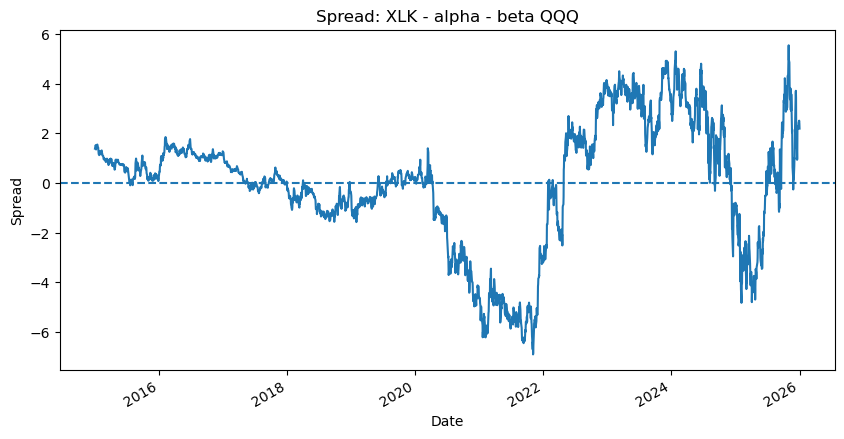

In [8]:
import matplotlib.pyplot as plt

ax = spread.plot(figsize=(10, 5))

ax.axhline(spread.mean(), linestyle="--")
ax.set_title(f"Spread: {ticker_y} - alpha - beta {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
plt.show()

In [9]:
print("alpha:", alpha)
print("beta:", beta)
print(spread.describe())

alpha: -6.083477534786367
beta: 0.24068529955583914
count    2.766000e+03
mean    -4.282780e-14
std      2.489940e+00
min     -6.904320e+00
25%     -1.007093e+00
50%      2.242802e-01
75%      1.381208e+00
max      5.553757e+00
Name: XLK_QQQ_spread, dtype: float64


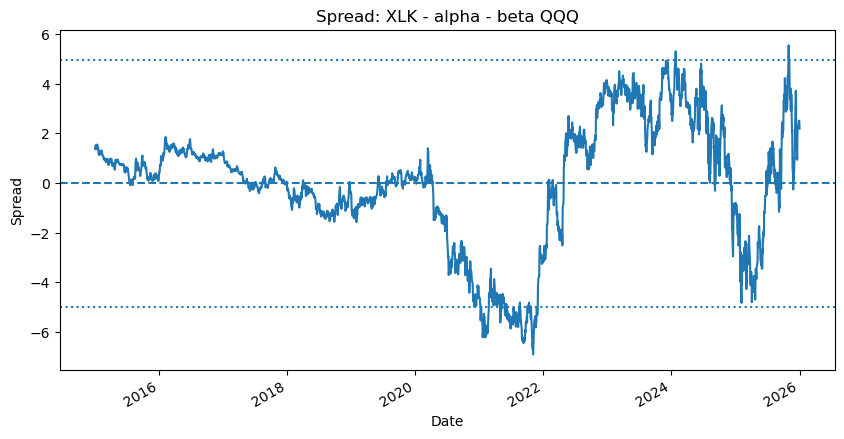

In [10]:
ax = spread.plot(figsize=(10, 5))

ax.axhline(spread.mean(), linestyle="--")
ax.axhline(spread.mean() + 2 * spread.std(), linestyle=":")
ax.axhline(spread.mean() - 2 * spread.std(), linestyle=":")

ax.set_title(f"Spread: {ticker_y} - alpha - beta {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
plt.show()

In [11]:
from src.spread import compute_zscore

In [12]:
zscore = compute_zscore(spread)
print(zscore.head())
print(zscore.describe())

Date
2015-01-02    0.556938
2015-01-05    0.580274
2015-01-06    0.614909
2015-01-07    0.560126
2015-01-08    0.544304
Name: XLK_QQQ_spread_zscore, dtype: float64
count    2.766000e+03
mean    -5.137692e-17
std      1.000000e+00
min     -2.772886e+00
25%     -4.044649e-01
50%      9.007456e-02
75%      5.547155e-01
max      2.230479e+00
Name: XLK_QQQ_spread_zscore, dtype: float64


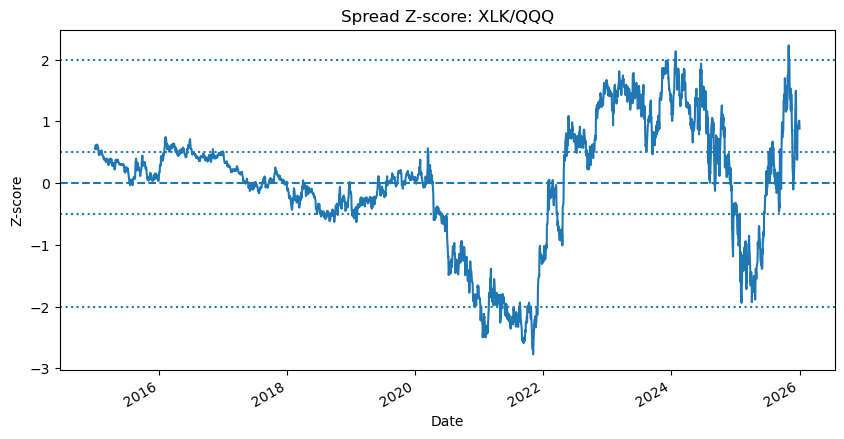

In [13]:
ax = zscore.plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.axhline(2, linestyle=":")
ax.axhline(-2, linestyle=":")
ax.axhline(0.5, linestyle=":")
ax.axhline(-0.5, linestyle=":")

ax.set_title(f"Spread Z-score: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
plt.show()

In [14]:
print(zscore.describe())

count    2.766000e+03
mean    -5.137692e-17
std      1.000000e+00
min     -2.772886e+00
25%     -4.044649e-01
50%      9.007456e-02
75%      5.547155e-01
max      2.230479e+00
Name: XLK_QQQ_spread_zscore, dtype: float64


In [15]:
from src.signals import generate_spread_positions

positions = generate_spread_positions(
    zscore=zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

print(positions.head())
print(positions.value_counts())

Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64
XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64


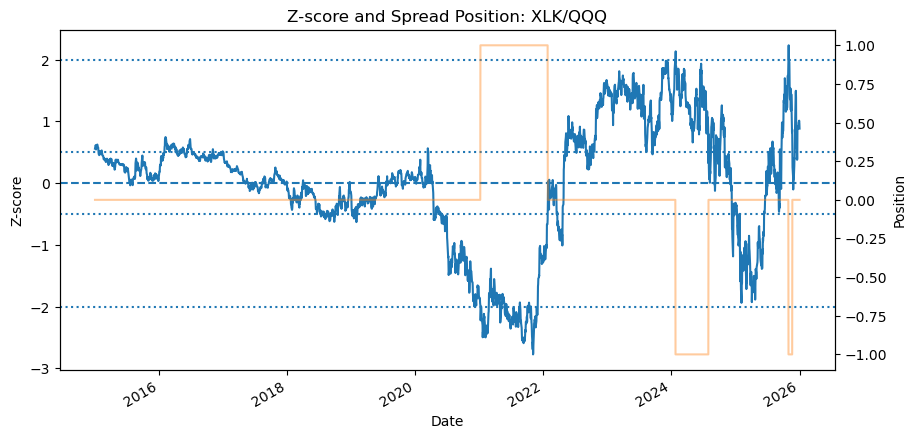

In [16]:
ax = zscore.plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.axhline(2, linestyle=":")
ax.axhline(-2, linestyle=":")
ax.axhline(0.5, linestyle=":")
ax.axhline(-0.5, linestyle=":")

ax2 = positions.plot(secondary_y=True, alpha=0.4)

ax.set_title(f"Z-score and Spread Position: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax2.set_ylabel("Position")

plt.show()

In [17]:
print(positions.value_counts())
print(positions.head(20))
print(positions.tail(20))

XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64
Date
2015-01-02    0
2015-01-05    0
2015-01-06    0
2015-01-07    0
2015-01-08    0
2015-01-09    0
2015-01-12    0
2015-01-13    0
2015-01-14    0
2015-01-15    0
2015-01-16    0
2015-01-20    0
2015-01-21    0
2015-01-22    0
2015-01-23    0
2015-01-26    0
2015-01-27    0
2015-01-28    0
2015-01-29    0
2015-01-30    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64
Date
2025-12-03    0
2025-12-04    0
2025-12-05    0
2025-12-08    0
2025-12-09    0
2025-12-10    0
2025-12-11    0
2025-12-12    0
2025-12-15    0
2025-12-16    0
2025-12-17    0
2025-12-18    0
2025-12-19    0
2025-12-22    0
2025-12-23    0
2025-12-24    0
2025-12-26    0
2025-12-29    0
2025-12-30    0
2025-12-31    0
Name: XLK_QQQ_spread_zscore_position, dtype: int64


In [18]:
from src.backtest import compute_strategy_returns

strategy_returns = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
)

print(strategy_returns.head())
print(strategy_returns.describe())
print(strategy_returns.isna().sum())

Date
2015-01-05    0.0
2015-01-06    0.0
2015-01-07   -0.0
2015-01-08   -0.0
2015-01-09    0.0
Name: XLK_QQQ_strategy_returns, dtype: float64
count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
0


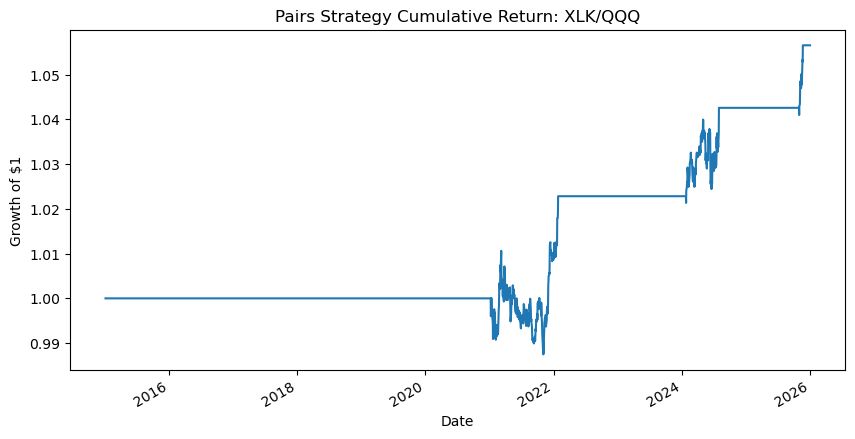

In [19]:
cumulative_strategy_returns = (1 + strategy_returns).cumprod()

ax = cumulative_strategy_returns.plot(figsize=(10, 5))

ax.set_title(f"Pairs Strategy Cumulative Return: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [20]:
print(strategy_returns.describe())
print(cumulative_strategy_returns.tail())

count    2765.000000
mean        0.000020
std         0.000678
min        -0.005636
25%         0.000000
50%         0.000000
75%         0.000000
max         0.006537
Name: XLK_QQQ_strategy_returns, dtype: float64
Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns, dtype: float64


In [21]:
from src.metrics import compute_cumulative_returns, compute_performance_metrics

cumulative_strategy_returns = compute_cumulative_returns(strategy_returns)
metrics = compute_performance_metrics(strategy_returns)

print(cumulative_strategy_returns.tail())
print(metrics)

Date
2025-12-24    1.056531
2025-12-26    1.056531
2025-12-29    1.056531
2025-12-30    1.056531
2025-12-31    1.056531
Name: XLK_QQQ_strategy_returns_cumulative_returns, dtype: float64
{'total_return': 0.056531321191390704, 'annualized_return': 0.005024436911625685, 'annualized_volatility': 0.01075650296547194, 'sharpe_ratio': 0.4713149865152298, 'max_drawdown': -0.02289761040244509}


In [22]:
for key, value in metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0565
annualized_return: 0.0050
annualized_volatility: 0.0108
sharpe_ratio: 0.4713
max_drawdown: -0.0229


In [23]:
print(positions.value_counts())

XLK_QQQ_spread_zscore_position
 0    2356
 1     265
-1     145
Name: count, dtype: int64


In [24]:
position_changes = positions.diff().fillna(0)

print(position_changes.value_counts())

XLK_QQQ_spread_zscore_position
 0.0    2760
 1.0       3
-1.0       3
Name: count, dtype: int64


In [25]:
n_position_changes = (positions.diff().fillna(0) != 0).sum()

days_in_market = (positions != 0).sum()
total_days = len(positions)

print("Number of position changes:", n_position_changes)
print("Days in market:", days_in_market)
print("Total days:", total_days)
print("Fraction in market:", days_in_market / total_days)

Number of position changes: 6
Days in market: 410
Total days: 2766
Fraction in market: 0.14822848879248013


In [26]:
strategy_returns_0bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=0.0,
)

strategy_returns_5bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=5.0,
)

strategy_returns_10bps = compute_strategy_returns(
    prices=prices,
    positions=positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=10.0,
)

In [27]:
for label, rets in {
    "0 bps": strategy_returns_0bps,
    "5 bps": strategy_returns_5bps,
    "10 bps": strategy_returns_10bps,
}.items():
    metrics = compute_performance_metrics(rets)

    print(label)
    for key, value in metrics.items():
        print(f"  {key}: {value:.4f}")
    print()

0 bps
  total_return: 0.0565
  annualized_return: 0.0050
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4713
  max_drawdown: -0.0229

5 bps
  total_return: 0.0534
  annualized_return: 0.0047
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4444
  max_drawdown: -0.0229

10 bps
  total_return: 0.0502
  annualized_return: 0.0045
  annualized_volatility: 0.0108
  sharpe_ratio: 0.4172
  max_drawdown: -0.0229



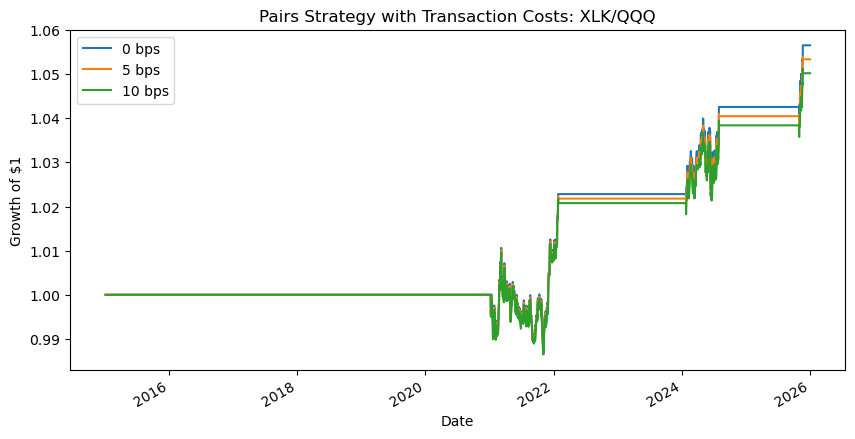

In [28]:
import pandas as pd

cum_0bps = compute_cumulative_returns(strategy_returns_0bps)
cum_5bps = compute_cumulative_returns(strategy_returns_5bps)
cum_10bps = compute_cumulative_returns(strategy_returns_10bps)

comparison = pd.concat(
    {
        "0 bps": cum_0bps,
        "5 bps": cum_5bps,
        "10 bps": cum_10bps,
    },
    axis=1,
)

ax = comparison.plot(figsize=(10, 5))

ax.set_title(f"Pairs Strategy with Transaction Costs: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [29]:
from src.trades import build_trade_log

trade_log = build_trade_log(
    positions=positions,
    strategy_returns=strategy_returns_5bps,
)

print(trade_log)

  entry_date  exit_date     direction  holding_days  trade_return
0 2021-01-07 2022-01-26   long_spread           266      0.022306
1 2024-01-24 2024-07-30  short_spread           130      0.018795
2 2025-10-29 2025-11-20  short_spread            17      0.012889


In [30]:
print(trade_log["trade_return"].describe())
print("Number of trades:", len(trade_log))
print("Average holding days:", trade_log["holding_days"].mean())
print("Win rate:", (trade_log["trade_return"] > 0).mean())

count    3.000000
mean     0.017996
std      0.004759
min      0.012889
25%      0.015842
50%      0.018795
75%      0.020550
max      0.022306
Name: trade_return, dtype: float64
Number of trades: 3
Average holding days: 137.66666666666666
Win rate: 1.0


In [31]:
from src.spread import compute_rolling_zscore

rolling_zscore = compute_rolling_zscore(spread, window=60, lag=True)

print(rolling_zscore.head())
print(rolling_zscore.describe())

Date
2015-03-31   -0.947862
2015-04-01   -0.500025
2015-04-02   -0.563569
2015-04-06   -0.605981
2015-04-07   -0.579255
Name: XLK_QQQ_spread_rolling_zscore, dtype: float64
count    2706.000000
mean       -0.127431
std         1.414748
min        -4.392822
25%        -1.156881
50%        -0.226143
75%         0.910360
max         5.030923
Name: XLK_QQQ_spread_rolling_zscore, dtype: float64


In [32]:
rolling_positions = generate_spread_positions(
    zscore = rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

print(rolling_positions.value_counts())

XLK_QQQ_spread_rolling_zscore_position
 0    1557
 1     615
-1     534
Name: count, dtype: int64


In [33]:
print("Number of position changes:", (rolling_positions.diff().fillna(0) != 0).sum())
print("Days in market:", (rolling_positions != 0).sum())
print("Total days:", len(rolling_positions))
print("Fraction in market:", (rolling_positions != 0).sum() / len(rolling_positions))

Number of position changes: 124
Days in market: 1149
Total days: 2706
Fraction in market: 0.4246119733924612


In [34]:
rolling_strategy_returns = compute_strategy_returns(
    prices=prices,
    positions=rolling_positions,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    beta=beta,
    transaction_cost_bps=5.0,
)

rolling_metrics = compute_performance_metrics(rolling_strategy_returns)

for key, value in rolling_metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0725
annualized_return: 0.0065
annualized_volatility: 0.0198
sharpe_ratio: 0.3388
max_drawdown: -0.0347


In [35]:
rolling_trade_log = build_trade_log(
    positions=rolling_positions,
    strategy_returns=rolling_strategy_returns,
)

print(rolling_trade_log)
print("Number of trades:", len(rolling_trade_log))
print("Win rate:", (rolling_trade_log["trade_return"]>0).mean())
print("Average holding days:", rolling_trade_log["holding_days"].mean())

   entry_date  exit_date     direction  holding_days  trade_return
0  2015-04-24 2015-04-30   long_spread             5      0.008823
1  2015-06-18 2015-08-20   long_spread            45     -0.001580
2  2015-08-24 2015-08-27  short_spread             4      0.011865
3  2015-09-28 2015-10-16  short_spread            15      0.010645
4  2016-01-08 2016-04-01  short_spread            58     -0.015856
..        ...        ...           ...           ...           ...
57 2024-09-03 2024-09-11   long_spread             7      0.008961
58 2024-12-10 2025-02-26   long_spread            52     -0.004567
59 2025-05-13 2025-05-22  short_spread             8      0.004705
60 2025-06-12 2025-08-11  short_spread            41     -0.006231
61 2025-09-22 2025-11-11  short_spread            37     -0.002588

[62 rows x 5 columns]
Number of trades: 62
Win rate: 0.7580645161290323
Average holding days: 19.532258064516128


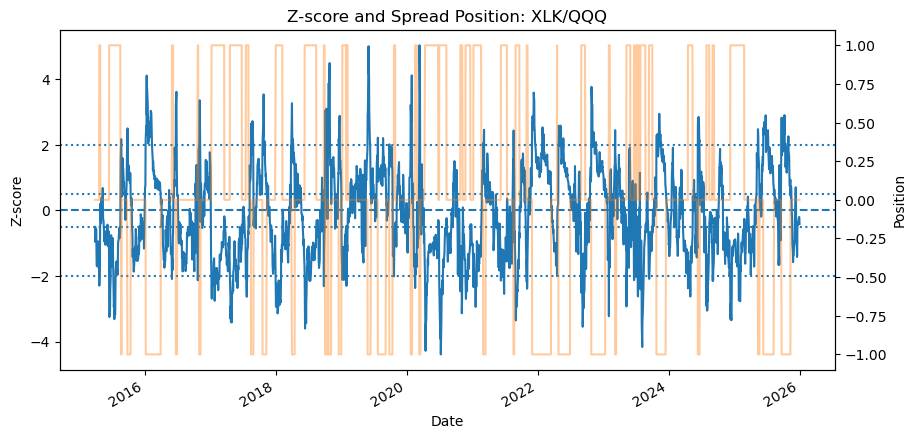

In [36]:
ax = rolling_zscore.plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.axhline(2, linestyle=":")
ax.axhline(-2, linestyle=":")
ax.axhline(0.5, linestyle=":")
ax.axhline(-0.5, linestyle=":")

ax2 = rolling_positions.plot(secondary_y=True, alpha=0.4)

ax.set_title(f"Z-score and Spread Position: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Z-score")
ax2.set_ylabel("Position")

plt.show()

In [37]:
print(len(rolling_zscore))
print(len(rolling_positions))
print(len(rolling_strategy_returns))

2706
2706
2706


In [38]:
print("Counts")
print(rolling_positions.value_counts())

print("Number of position changes:", (rolling_positions.diff().fillna(0) != 0).sum())
print("Days in market:", (rolling_positions != 0).sum())
print("Total days:", len(rolling_positions))
print("Fraction in market:", (rolling_positions != 0).sum() / len(rolling_positions))

for key, value in rolling_metrics.items():
    print(f"{key}: {value:.4f}")

Counts
XLK_QQQ_spread_rolling_zscore_position
 0    1557
 1     615
-1     534
Name: count, dtype: int64
Number of position changes: 124
Days in market: 1149
Total days: 2706
Fraction in market: 0.4246119733924612
total_return: 0.0725
annualized_return: 0.0065
annualized_volatility: 0.0198
sharpe_ratio: 0.3388
max_drawdown: -0.0347


In [39]:
from src.spread import compute_rolling_spread

rolling_spread_df = compute_rolling_spread(
    prices=prices,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    window=252,
)

print(rolling_spread_df.head())
print(rolling_spread_df.tail())
print(rolling_spread_df.describe())

               alpha      beta    spread
date                                    
2016-01-04  3.224805  0.153891 -0.022995
2016-01-05  3.180938  0.154318 -0.044361
2016-01-06  3.137034  0.154747 -0.124913
2016-01-07  3.087401  0.155230 -0.183728
2016-01-08  3.034071  0.155750 -0.199248
                alpha      beta    spread
date                                     
2025-12-24 -31.000883  0.285479 -0.754000
2025-12-26 -30.986384  0.285439 -0.502977
2025-12-29 -30.978341  0.285414 -0.294135
2025-12-30 -30.963797  0.285385 -0.339401
2025-12-31 -30.950951  0.285357 -0.313973
             alpha         beta       spread
count  2514.000000  2514.000000  2514.000000
mean     -1.032526     0.215200     0.108681
std       7.955702     0.028811     1.321033
min     -31.424265     0.149119    -7.770455
25%      -4.754028     0.196481    -0.351182
50%      -1.117382     0.212595     0.142844
75%       2.240587     0.238097     0.635051
max      19.046538     0.286640     4.982690


In [40]:
print(rolling_spread_df.shape)

(2514, 3)


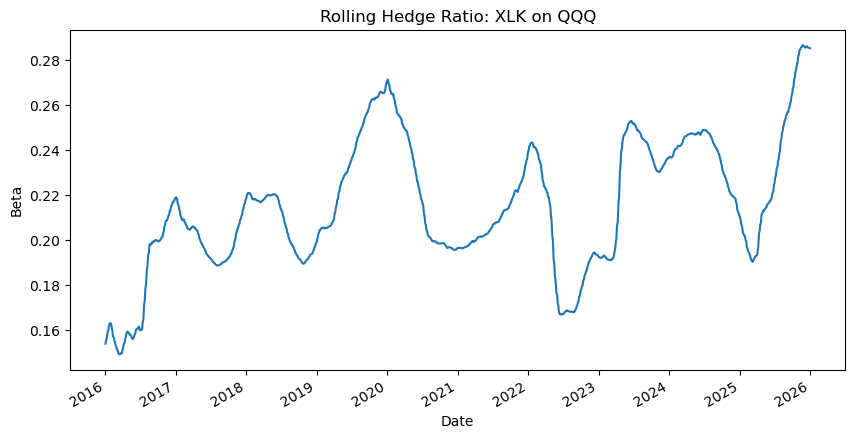

In [41]:
ax = rolling_spread_df["beta"].plot(figsize=(10, 5))

ax.set_title(f"Rolling Hedge Ratio: {ticker_y} on {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Beta")
plt.show()

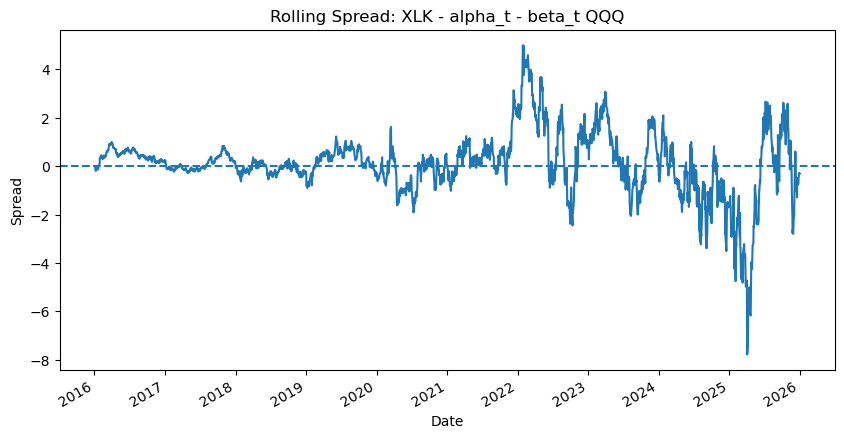

In [42]:
ax = rolling_spread_df["spread"].plot(figsize=(10, 5))

ax.axhline(0, linestyle="--")
ax.set_title(f"Rolling Spread: {ticker_y} - alpha_t - beta_t {ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Spread")
plt.show()

In [43]:
rolling_spread = rolling_spread_df["spread"]

rolling_zscore = compute_rolling_zscore(
    spread=rolling_spread,
    window=60,
    lag=True,
)

rolling_positions = generate_spread_positions(
    zscore=rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

In [44]:
print(rolling_spread_df.shape)
print(rolling_spread_df.head())
print(rolling_spread_df[["alpha", "beta", "spread"]].describe())

(2514, 3)
               alpha      beta    spread
date                                    
2016-01-04  3.224805  0.153891 -0.022995
2016-01-05  3.180938  0.154318 -0.044361
2016-01-06  3.137034  0.154747 -0.124913
2016-01-07  3.087401  0.155230 -0.183728
2016-01-08  3.034071  0.155750 -0.199248
             alpha         beta       spread
count  2514.000000  2514.000000  2514.000000
mean     -1.032526     0.215200     0.108681
std       7.955702     0.028811     1.321033
min     -31.424265     0.149119    -7.770455
25%      -4.754028     0.196481    -0.351182
50%      -1.117382     0.212595     0.142844
75%       2.240587     0.238097     0.635051
max      19.046538     0.286640     4.982690


In [45]:
from src.backtest import compute_strategy_returns_dynamic_beta

rolling_spread = rolling_spread_df["spread"]
rolling_beta = rolling_spread_df["beta"]

rolling_zscore = compute_rolling_zscore(
    spread=rolling_spread,
    window=60,
    lag=True,
)

rolling_positions = generate_spread_positions(
    zscore=rolling_zscore,
    entry_threshold=2.0,
    exit_threshold=0.5,
)

dynamic_beta_returns = compute_strategy_returns_dynamic_beta(
    prices=prices,
    positions=rolling_positions,
    beta=rolling_beta,
    ticker_y=ticker_y,
    ticker_x=ticker_x,
    transaction_cost_bps=5.0,
)

dynamic_beta_metrics = compute_performance_metrics(dynamic_beta_returns)

for key, value in dynamic_beta_metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0738
annualized_return: 0.0073
annualized_volatility: 0.0192
sharpe_ratio: 0.3910
max_drawdown: -0.0301


In [46]:
print(len(rolling_spread))
print(len(rolling_zscore))
print(len(rolling_positions))
print(len(dynamic_beta_returns))
print(rolling_positions.value_counts())

2514
2454
2454
2454
spread_rolling_zscore_position
 0    1459
 1     541
-1     454
Name: count, dtype: int64


In [92]:
comparison_metrics = pd.DataFrame(
    {
        "fixed_beta_rolling_zscore": compute_performance_metrics(rolling_strategy_returns),
        "dynamic_beta_rolling_zscore": compute_performance_metrics(dynamic_beta_returns),
    }
).T

print(comparison_metrics)

                             total_return  annualized_return  \
fixed_beta_rolling_zscore        0.072461           0.006536   
dynamic_beta_rolling_zscore      0.073807           0.007339   

                             annualized_volatility  sharpe_ratio  max_drawdown  
fixed_beta_rolling_zscore                 0.019807      0.338814     -0.034661  
dynamic_beta_rolling_zscore               0.019173      0.390988     -0.030140  


In [94]:
print(comparison_metrics.round(4))

                             total_return  annualized_return  \
fixed_beta_rolling_zscore          0.0725             0.0065   
dynamic_beta_rolling_zscore        0.0738             0.0073   

                             annualized_volatility  sharpe_ratio  max_drawdown  
fixed_beta_rolling_zscore                   0.0198        0.3388       -0.0347  
dynamic_beta_rolling_zscore                 0.0192        0.3910       -0.0301  


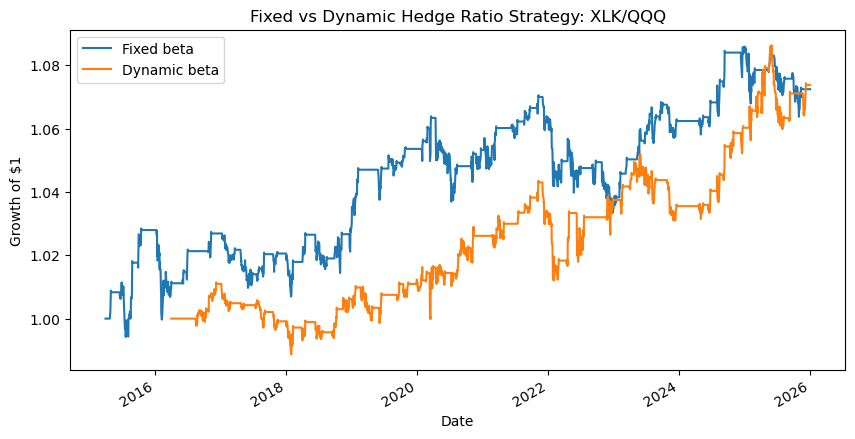

In [96]:
fixed_cum = compute_cumulative_returns(rolling_strategy_returns)
dynamic_cum = compute_cumulative_returns(dynamic_beta_returns)

comparison_cum = pd.concat(
    {
        "Fixed beta": fixed_cum,
        "Dynamic beta": dynamic_cum,
    },
    axis=1,
)

ax = comparison_cum.plot(figsize=(10, 5))

ax.set_title(f"Fixed vs Dynamic Hedge Ratio Strategy: {ticker_y}/{ticker_x}")
ax.set_xlabel("Date")
ax.set_ylabel("Growth of $1")
plt.show()

In [98]:
dynamic_trade_log = build_trade_log(
    positions=rolling_positions,
    strategy_returns=dynamic_beta_returns,
)

print(dynamic_trade_log)
print("Number of trades:", len(dynamic_trade_log))
print("Win rate:", (dynamic_trade_log["trade_return"] > 0).mean())
print("Average holding days:", dynamic_trade_log["holding_days"].mean())
print(dynamic_trade_log["trade_return"].describe())

   entry_date  exit_date     direction  holding_days  trade_return
0  2016-08-12 2016-10-12   long_spread            43      0.003276
1  2016-10-24 2016-10-28   long_spread             5      0.004474
2  2016-11-09 2016-12-07   long_spread            20      0.004690
3  2017-01-05 2017-02-24   long_spread            35     -0.005548
4  2017-04-25 2017-05-10   long_spread            12     -0.000101
5  2017-07-12 2017-07-24  short_spread             9      0.001562
6  2017-08-01 2017-09-06  short_spread            26     -0.002716
7  2017-10-20 2017-11-15  short_spread            19     -0.002433
8  2018-01-02 2018-02-09   long_spread            28     -0.001477
9  2018-03-28 2018-04-18  short_spread            15      0.002231
10 2018-06-13 2018-07-23   long_spread            28     -0.002718
11 2018-09-14 2018-09-27  short_spread            10      0.002833
12 2018-10-03 2018-10-10  short_spread             6      0.005449
13 2018-11-14 2018-11-15   long_spread             2      0.00

In [100]:
print(comparison_metrics.round(4))
print("Number of trades:", len(dynamic_trade_log))
print("Win rate:", (dynamic_trade_log["trade_return"] > 0).mean())
print("Average holding days:", dynamic_trade_log["holding_days"].mean())

                             total_return  annualized_return  \
fixed_beta_rolling_zscore          0.0725             0.0065   
dynamic_beta_rolling_zscore        0.0738             0.0073   

                             annualized_volatility  sharpe_ratio  max_drawdown  
fixed_beta_rolling_zscore                   0.0198        0.3388       -0.0347  
dynamic_beta_rolling_zscore                 0.0192        0.3910       -0.0301  
Number of trades: 55
Win rate: 0.7454545454545455
Average holding days: 19.09090909090909


In [146]:
def run_dynamic_beta_backtest(
    prices,
    ticker_y,
    ticker_x,
    hedge_window=252,
    zscore_window=60,
    entry_threshold=2.0,
    exit_threshold=0.5,
    transaction_cost_bps=5.0,
    evaluation_start=None,
    evaluation_end=None,
):
    rolling_spread_df = compute_rolling_spread(
        prices=prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        window=hedge_window,
    )

    rolling_spread = rolling_spread_df["spread"]
    rolling_beta = rolling_spread_df["beta"]

    rolling_zscore = compute_rolling_zscore(
        spread=rolling_spread,
        window=zscore_window,
        lag=True,
    )

    positions = generate_spread_positions(
        zscore=rolling_zscore,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold,
    )

    strategy_returns = compute_strategy_returns_dynamic_beta(
        prices=prices,
        positions=positions,
        beta=rolling_beta,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        transaction_cost_bps=transaction_cost_bps,
    )

    if evaluation_start is not None:
        strategy_returns = strategy_returns.loc[evaluation_start:]

    if evaluation_end is not None:
        strategy_returns = strategy_returns.loc[:evaluation_end]

    positions_eval = positions.reindex(strategy_returns.index).ffill().fillna(0)

    metrics = compute_performance_metrics(strategy_returns)

    trade_log = build_trade_log(
        positions=positions,
        strategy_returns=strategy_returns,
    )

    metrics["n_trades"] = len(trade_log)
    metrics["win_rate"] = (
        (trade_log["trade_return"] > 0).mean()
        if len(trade_log) > 0
        else float("nan")
    )
    metrics["avg_holding_days"] = (
        trade_log["holding_days"].mean()
        if len(trade_log) > 0
        else float("nan")
    )
    metrics["days_in_market_frac"] = (positions_eval != 0).mean()

    return metrics

In [104]:
test_metrics = run_dynamic_beta_backtest(
    prices=prices,
    ticker_y="XLK",
    ticker_x="QQQ",
    hedge_window=252,
    zscore_window=60,
    entry_threshold=2.0,
    exit_threshold=0.5,
    transaction_cost_bps=5.0,
)

for key, value in test_metrics.items():
    print(f"{key}: {value:.4f}")

total_return: 0.0738
annualized_return: 0.0073
annualized_volatility: 0.0192
sharpe_ratio: 0.3910
max_drawdown: -0.0301
n_trades: 55.0000
win_rate: 0.7455
avg_holding_days: 19.0909
days_in_market_frac: 0.4055


In [106]:
zscore_windows = [30, 60, 90, 120]
entry_thresholds = [1.5, 2.0, 2.5]

rows = []

for z_window in zscore_windows:
    for entry in entry_thresholds:
        metrics = run_dynamic_beta_backtest(
            prices=prices,
            ticker_y="XLK",
            ticker_x="QQQ",
            hedge_window=252,
            zscore_window=z_window,
            entry_threshold=entry,
            exit_threshold=0.5,
            transaction_cost_bps=5.0,
        )

        metrics["zscore_window"] = z_window
        metrics["entry_threshold"] = entry

        rows.append(metrics)

sensitivity = pd.DataFrame(rows)

print(sensitivity)

    total_return  annualized_return  annualized_volatility  sharpe_ratio  \
0      -0.040014          -0.004134               0.022624     -0.171811   
1      -0.027449          -0.002820               0.020127     -0.130233   
2      -0.008543          -0.000870               0.018101     -0.039045   
3       0.059700           0.005972               0.021957      0.282160   
4       0.073807           0.007339               0.019173      0.390988   
5       0.068150           0.006793               0.015642      0.440629   
6       0.064274           0.006497               0.021012      0.318709   
7       0.042685           0.004355               0.018617      0.242719   
8       0.033248           0.003406               0.015308      0.229778   
9       0.059378           0.006090               0.021527      0.292817   
10      0.080805           0.008213               0.018877      0.442740   
11      0.051348           0.005285               0.015148      0.355524   

    max_dra

In [109]:
sensitivity_sorted = sensitivity.sort_values(
    by="sharpe_ratio",
    ascending=False,
)

print(sensitivity_sorted.round(4))

    total_return  annualized_return  annualized_volatility  sharpe_ratio  \
10        0.0808             0.0082                 0.0189        0.4427   
5         0.0681             0.0068                 0.0156        0.4406   
4         0.0738             0.0073                 0.0192        0.3910   
11        0.0513             0.0053                 0.0151        0.3555   
6         0.0643             0.0065                 0.0210        0.3187   
9         0.0594             0.0061                 0.0215        0.2928   
3         0.0597             0.0060                 0.0220        0.2822   
7         0.0427             0.0044                 0.0186        0.2427   
8         0.0332             0.0034                 0.0153        0.2298   
2        -0.0085            -0.0009                 0.0181       -0.0390   
1        -0.0274            -0.0028                 0.0201       -0.1302   
0        -0.0400            -0.0041                 0.0226       -0.1718   

    max_dra

In [111]:
cols = [
    "zscore_window",
    "entry_threshold",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "days_in_market_frac",
]

print(sensitivity_sorted[cols].round(4))

    zscore_window  entry_threshold  total_return  annualized_return  \
10            120              2.0        0.0808             0.0082   
5              60              2.5        0.0681             0.0068   
4              60              2.0        0.0738             0.0073   
11            120              2.5        0.0513             0.0053   
6              90              1.5        0.0643             0.0065   
9             120              1.5        0.0594             0.0061   
3              60              1.5        0.0597             0.0060   
7              90              2.0        0.0427             0.0044   
8              90              2.5        0.0332             0.0034   
2              30              2.5       -0.0085            -0.0009   
1              30              2.0       -0.0274            -0.0028   
0              30              1.5       -0.0400            -0.0041   

    annualized_volatility  sharpe_ratio  max_drawdown  n_trades  win_rate  \

In [113]:
sharpe_pivot = sensitivity.pivot(
    index="zscore_window",
    columns="entry_threshold",
    values="sharpe_ratio",
)

trades_pivot = sensitivity.pivot(
    index="zscore_window",
    columns="entry_threshold",
    values="n_trades",
)

print(sharpe_pivot.round(3))
print(trades_pivot)

entry_threshold    1.5    2.0    2.5
zscore_window                       
30              -0.172 -0.130 -0.039
60               0.282  0.391  0.441
90               0.319  0.243  0.230
120              0.293  0.443  0.356
entry_threshold  1.5  2.0  2.5
zscore_window                 
30               119   86   55
60                78   55   36
90                58   41   22
120               53   37   19


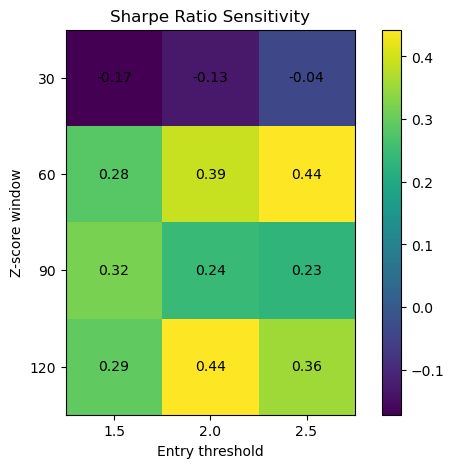

In [115]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(sharpe_pivot.values)

ax.set_xticks(range(len(sharpe_pivot.columns)))
ax.set_xticklabels(sharpe_pivot.columns)

ax.set_yticks(range(len(sharpe_pivot.index)))
ax.set_yticklabels(sharpe_pivot.index)

ax.set_xlabel("Entry threshold")
ax.set_ylabel("Z-score window")
ax.set_title("Sharpe Ratio Sensitivity")

for i in range(sharpe_pivot.shape[0]):
    for j in range(sharpe_pivot.shape[1]):
        value = sharpe_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.show()

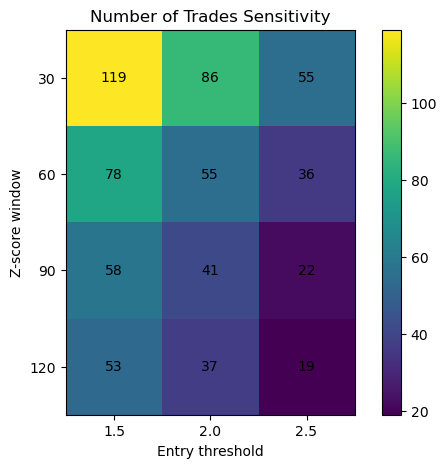

In [117]:
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(trades_pivot.values)

ax.set_xticks(range(len(trades_pivot.columns)))
ax.set_xticklabels(trades_pivot.columns)

ax.set_yticks(range(len(trades_pivot.index)))
ax.set_yticklabels(trades_pivot.index)

ax.set_xlabel("Entry threshold")
ax.set_ylabel("Z-score window")
ax.set_title("Number of Trades Sensitivity")

for i in range(trades_pivot.shape[0]):
    for j in range(trades_pivot.shape[1]):
        value = trades_pivot.iloc[i, j]
        ax.text(j, i, f"{value:.0f}", ha="center", va="center")

fig.colorbar(im, ax=ax)
plt.show()

In [119]:
top_pairs = ranked_pairs.head(10)

print(top_pairs)

   ticker_1 ticker_2  correlation
15      QQQ      XLK     0.974542
0       SPY      QQQ     0.933781
2       SPY      XLK     0.929819
6       SPY      XLY     0.899924
8       SPY      XLI     0.890521
19      QQQ      XLY     0.885982
54      XLF      XLI     0.873843
1       SPY      IWM     0.867231
33      IWM      XLI     0.857436
3       SPY      XLF     0.846784


In [121]:
pair_results = []

for _, row in top_pairs.iterrows():
    ticker_1 = row["ticker_1"]
    ticker_2 = row["ticker_2"]
    correlation = row["correlation"]

    print(f"Running {ticker_1}/{ticker_2}...")

    try:
        metrics = run_dynamic_beta_backtest(
            prices=prices,
            ticker_y=ticker_1,
            ticker_x=ticker_2,
            hedge_window=252,
            zscore_window=120,
            entry_threshold=2.0,
            exit_threshold=0.5,
            transaction_cost_bps=5.0,
        )

        metrics["ticker_y"] = ticker_1
        metrics["ticker_x"] = ticker_2
        metrics["correlation"] = correlation

        pair_results.append(metrics)

    except Exception as e:
        print(f"Failed on {ticker_1}/{ticker_2}: {e}")

Running QQQ/XLK...
Running SPY/QQQ...
Running SPY/XLK...
Running SPY/XLY...
Running SPY/XLI...
Running QQQ/XLY...
Running XLF/XLI...
Running SPY/IWM...
Running IWM/XLI...
Running SPY/XLF...


In [122]:
pair_results_df = pd.DataFrame(pair_results)

cols = [
    "ticker_y",
    "ticker_x",
    "correlation",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

pair_results_df = pair_results_df[cols]

print(pair_results_df.sort_values("sharpe_ratio", ascending=False).round(4))

  ticker_y ticker_x  correlation  total_return  annualized_return  \
2      SPY      XLK       0.9298        0.1347             0.0134   
0      QQQ      XLK       0.9745        0.0604             0.0062   
6      XLF      XLI       0.8738        0.0570             0.0059   
4      SPY      XLI       0.8905        0.0469             0.0048   
8      IWM      XLI       0.8574       -0.0595            -0.0064   
7      SPY      IWM       0.8672       -0.0713            -0.0078   
5      QQQ      XLY       0.8860       -0.0814            -0.0089   
1      SPY      QQQ       0.9338       -0.0635            -0.0069   
3      SPY      XLY       0.8999       -0.1270            -0.0142   
9      SPY      XLF       0.8468       -0.1873            -0.0216   

   annualized_volatility  sharpe_ratio  max_drawdown  n_trades  win_rate  \
2                 0.0281        0.4876       -0.0912        34    0.8235   
0                 0.0180        0.3525       -0.0327        35    0.6857   
6           

In [125]:
print(pair_results_df.sort_values("sharpe_ratio", ascending=False).round(4))

  ticker_y ticker_x  correlation  total_return  annualized_return  \
2      SPY      XLK       0.9298        0.1347             0.0134   
0      QQQ      XLK       0.9745        0.0604             0.0062   
6      XLF      XLI       0.8738        0.0570             0.0059   
4      SPY      XLI       0.8905        0.0469             0.0048   
8      IWM      XLI       0.8574       -0.0595            -0.0064   
7      SPY      IWM       0.8672       -0.0713            -0.0078   
5      QQQ      XLY       0.8860       -0.0814            -0.0089   
1      SPY      QQQ       0.9338       -0.0635            -0.0069   
3      SPY      XLY       0.8999       -0.1270            -0.0142   
9      SPY      XLF       0.8468       -0.1873            -0.0216   

   annualized_volatility  sharpe_ratio  max_drawdown  n_trades  win_rate  \
2                 0.0281        0.4876       -0.0912        34    0.8235   
0                 0.0180        0.3525       -0.0327        35    0.6857   
6           

In [127]:
directional_pair_results = []

top_pairs = ranked_pairs.head(10)

for _, row in top_pairs.iterrows():
    ticker_a = row["ticker_1"]
    ticker_b = row["ticker_2"]
    correlation = row["correlation"]

    directions = [
        (ticker_a, ticker_b),
        (ticker_b, ticker_a),
    ]

    for ticker_y, ticker_x in directions:
        print(f"Running {ticker_y} on {ticker_x}...")

        try:
            metrics = run_dynamic_beta_backtest(
                prices=prices,
                ticker_y=ticker_y,
                ticker_x=ticker_x,
                hedge_window=252,
                zscore_window=120,
                entry_threshold=2.0,
                exit_threshold=0.5,
                transaction_cost_bps=5.0,
            )

            metrics["ticker_y"] = ticker_y
            metrics["ticker_x"] = ticker_x
            metrics["pair"] = f"{ticker_y}/{ticker_x}"
            metrics["correlation"] = correlation

            directional_pair_results.append(metrics)

        except Exception as e:
            print(f"Failed on {ticker_y}/{ticker_x}: {e}")

Running QQQ on XLK...
Running XLK on QQQ...
Running SPY on QQQ...
Running QQQ on SPY...
Running SPY on XLK...
Running XLK on SPY...
Running SPY on XLY...
Running XLY on SPY...
Running SPY on XLI...
Running XLI on SPY...
Running QQQ on XLY...
Running XLY on QQQ...
Running XLF on XLI...
Running XLI on XLF...
Running SPY on IWM...
Running IWM on SPY...
Running IWM on XLI...
Running XLI on IWM...
Running SPY on XLF...
Running XLF on SPY...


In [128]:
directional_pair_results_df = pd.DataFrame(directional_pair_results)

cols = [
    "pair",
    "ticker_y",
    "ticker_x",
    "correlation",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

directional_pair_results_df = directional_pair_results_df[cols]

print(
    directional_pair_results_df
    .sort_values("sharpe_ratio", ascending=False)
    .round(4)
)

       pair ticker_y ticker_x  correlation  total_return  annualized_return  \
17  XLI/IWM      XLI      IWM       0.8574        0.2190             0.0211   
4   SPY/XLK      SPY      XLK       0.9298        0.1347             0.0134   
1   XLK/QQQ      XLK      QQQ       0.9745        0.0808             0.0082   
0   QQQ/XLK      QQQ      XLK       0.9745        0.0604             0.0062   
13  XLI/XLF      XLI      XLF       0.8738        0.0793             0.0081   
12  XLF/XLI      XLF      XLI       0.8738        0.0570             0.0059   
8   SPY/XLI      SPY      XLI       0.8905        0.0469             0.0048   
5   XLK/SPY      XLK      SPY       0.9298       -0.0072            -0.0008   
9   XLI/SPY      XLI      SPY       0.8905       -0.0330            -0.0035   
11  XLY/QQQ      XLY      QQQ       0.8860       -0.0482            -0.0052   
16  IWM/XLI      IWM      XLI       0.8574       -0.0595            -0.0064   
14  SPY/IWM      SPY      IWM       0.8672       -0.

In [131]:
train_start = "2015-01-01"
train_end = "2019-12-31"

test_start = "2020-01-01"
test_end = "2026-01-01"

In [133]:
train_prices = prices.loc[train_start:train_end]
train_returns = compute_simple_returns(train_prices)

print(train_prices.shape)
print(train_returns.shape)

(1258, 15)
(1257, 15)


In [135]:
train_ranked_pairs = rank_pairs_by_correlation(train_returns)

print(train_ranked_pairs.head(10).round(4))

    ticker_1 ticker_2  correlation
15       QQQ      XLK       0.9729
0        SPY      QQQ       0.9272
2        SPY      XLK       0.9192
6        SPY      XLY       0.9121
8        SPY      XLI       0.9014
19       QQQ      XLY       0.8889
1        SPY      IWM       0.8711
3        SPY      XLF       0.8537
42       XLK      XLY       0.8487
100      TLT      LQD       0.8429


In [152]:
def run_dynamic_beta_backtest(
    prices,
    ticker_y,
    ticker_x,
    hedge_window=252,
    zscore_window=120,
    entry_threshold=2.0,
    exit_threshold=0.5,
    transaction_cost_bps=5.0,
    evaluation_start=None,
    evaluation_end=None,
):
    rolling_spread_df = compute_rolling_spread(
        prices=prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        window=hedge_window,
    )

    rolling_spread = rolling_spread_df["spread"]
    rolling_beta = rolling_spread_df["beta"]

    rolling_zscore = compute_rolling_zscore(
        spread=rolling_spread,
        window=zscore_window,
        lag=True,
    )

    positions = generate_spread_positions(
        zscore=rolling_zscore,
        entry_threshold=entry_threshold,
        exit_threshold=exit_threshold,
    )

    strategy_returns = compute_strategy_returns_dynamic_beta(
        prices=prices,
        positions=positions,
        beta=rolling_beta,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        transaction_cost_bps=transaction_cost_bps,
    )

    # Filter returns to evaluation period
    if evaluation_start is not None:
        strategy_returns = strategy_returns.loc[evaluation_start:]

    if evaluation_end is not None:
        strategy_returns = strategy_returns.loc[:evaluation_end]

    # Align positions to evaluation-period returns
    positions_eval = positions.reindex(strategy_returns.index).ffill().fillna(0)

    # Compute metrics only on evaluation-period returns
    metrics = compute_performance_metrics(strategy_returns)

    # Build trade log only on evaluation-period positions/returns
    trade_log = build_trade_log(
        positions=positions_eval,
        strategy_returns=strategy_returns,
    )

    metrics["n_trades"] = len(trade_log)

    metrics["win_rate"] = (
        (trade_log["trade_return"] > 0).mean()
        if len(trade_log) > 0
        else float("nan")
    )

    metrics["avg_holding_days"] = (
        trade_log["holding_days"].mean()
        if len(trade_log) > 0
        else float("nan")
    )

    metrics["days_in_market_frac"] = (positions_eval != 0).mean()

    return metrics

In [154]:
oos_results = []

top_train_pairs = train_ranked_pairs.head(10)

for _, row in top_train_pairs.iterrows():
    ticker_a = row["ticker_1"]
    ticker_b = row["ticker_2"]
    train_correlation = row["correlation"]

    directions = [
        (ticker_a, ticker_b),
        (ticker_b, ticker_a),
    ]

    for ticker_y, ticker_x in directions:
        print(f"Running OOS {ticker_y}/{ticker_x}...")

        try:
            metrics = run_dynamic_beta_backtest(
                prices=prices,
                ticker_y=ticker_y,
                ticker_x=ticker_x,
                hedge_window=252,
                zscore_window=120,
                entry_threshold=2.0,
                exit_threshold=0.5,
                transaction_cost_bps=5.0,
                evaluation_start=test_start,
                evaluation_end=test_end,
            )

            metrics["pair"] = f"{ticker_y}/{ticker_x}"
            metrics["ticker_y"] = ticker_y
            metrics["ticker_x"] = ticker_x
            metrics["train_correlation"] = train_correlation

            oos_results.append(metrics)

        except Exception as e:
            print(f"Failed on {ticker_y}/{ticker_x}: {e}")

Running OOS QQQ/XLK...
Running OOS XLK/QQQ...
Running OOS SPY/QQQ...
Running OOS QQQ/SPY...
Running OOS SPY/XLK...
Running OOS XLK/SPY...
Running OOS SPY/XLY...
Running OOS XLY/SPY...
Running OOS SPY/XLI...
Running OOS XLI/SPY...
Running OOS QQQ/XLY...
Running OOS XLY/QQQ...
Running OOS SPY/IWM...
Running OOS IWM/SPY...
Running OOS SPY/XLF...
Running OOS XLF/SPY...
Running OOS XLK/XLY...
Running OOS XLY/XLK...
Running OOS TLT/LQD...
Running OOS LQD/TLT...


In [155]:
oos_results_df = pd.DataFrame(oos_results)

cols = [
    "pair",
    "ticker_y",
    "ticker_x",
    "train_correlation",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

oos_results_df = oos_results_df[cols]

print(
    oos_results_df
    .sort_values("sharpe_ratio", ascending=False)
    .round(4)
)

       pair ticker_y ticker_x  train_correlation  total_return  \
1   XLK/QQQ      XLK      QQQ             0.9729        0.0645   
0   QQQ/XLK      QQQ      XLK             0.9729        0.0578   
4   SPY/XLK      SPY      XLK             0.9192        0.0841   
17  XLY/XLK      XLY      XLK             0.8487        0.0175   
13  IWM/SPY      IWM      SPY             0.8711       -0.0300   
8   SPY/XLI      SPY      XLI             0.9014       -0.0179   
16  XLK/XLY      XLK      XLY             0.8487       -0.0692   
19  LQD/TLT      LQD      TLT             0.8429       -0.0575   
11  XLY/QQQ      XLY      QQQ             0.8889       -0.0658   
5   XLK/SPY      XLK      SPY             0.9192       -0.0485   
10  QQQ/XLY      QQQ      XLY             0.8889       -0.0680   
12  SPY/IWM      SPY      IWM             0.8711       -0.0984   
2   SPY/QQQ      SPY      QQQ             0.9272       -0.0744   
6   SPY/XLY      SPY      XLY             0.9121       -0.0958   
14  SPY/XL

In [158]:
top_train_pairs = train_ranked_pairs.head(10)

In [160]:
train_directional_results = []

for _, row in top_train_pairs.iterrows():
    ticker_a = row["ticker_1"]
    ticker_b = row["ticker_2"]
    train_correlation = row["correlation"]

    for ticker_y, ticker_x in [(ticker_a, ticker_b), (ticker_b, ticker_a)]:
        print(f"Running train {ticker_y}/{ticker_x}...")

        try:
            metrics = run_dynamic_beta_backtest(
                prices=prices,
                ticker_y=ticker_y,
                ticker_x=ticker_x,
                hedge_window=252,
                zscore_window=120,
                entry_threshold=2.0,
                exit_threshold=0.5,
                transaction_cost_bps=5.0,
                evaluation_start=None,
                evaluation_end=train_end,
            )

            metrics["pair"] = f"{ticker_y}/{ticker_x}"
            metrics["ticker_y"] = ticker_y
            metrics["ticker_x"] = ticker_x
            metrics["train_correlation"] = train_correlation

            train_directional_results.append(metrics)

        except Exception as e:
            print(f"Failed on train {ticker_y}/{ticker_x}: {e}")

Running train QQQ/XLK...
Running train XLK/QQQ...
Running train SPY/QQQ...
Running train QQQ/SPY...
Running train SPY/XLK...
Running train XLK/SPY...
Running train SPY/XLY...
Running train XLY/SPY...
Running train SPY/XLI...
Running train XLI/SPY...
Running train QQQ/XLY...
Running train XLY/QQQ...
Running train SPY/IWM...
Running train IWM/SPY...
Running train SPY/XLF...
Running train XLF/SPY...
Running train XLK/XLY...
Running train XLY/XLK...
Running train TLT/LQD...
Running train LQD/TLT...


In [161]:
train_directional_df = pd.DataFrame(train_directional_results)

cols = [
    "pair",
    "ticker_y",
    "ticker_x",
    "train_correlation",
    "total_return",
    "annualized_return",
    "annualized_volatility",
    "sharpe_ratio",
    "max_drawdown",
    "n_trades",
    "win_rate",
    "avg_holding_days",
    "days_in_market_frac",
]

train_directional_df = train_directional_df[cols]

print(
    train_directional_df
    .sort_values("sharpe_ratio", ascending=False)
    .round(4)
)

       pair ticker_y ticker_x  train_correlation  total_return  \
9   XLI/SPY      XLI      SPY             0.9014        0.0866   
8   SPY/XLI      SPY      XLI             0.9014        0.0659   
4   SPY/XLK      SPY      XLK             0.9192        0.0467   
5   XLK/SPY      XLK      SPY             0.9192        0.0434   
1   XLK/QQQ      XLK      QQQ             0.9729        0.0153   
12  SPY/IWM      SPY      IWM             0.8711        0.0301   
2   SPY/QQQ      SPY      QQQ             0.9272        0.0118   
3   QQQ/SPY      QQQ      SPY             0.9272        0.0111   
11  XLY/QQQ      XLY      QQQ             0.8889        0.0189   
17  XLY/XLK      XLY      XLK             0.8487        0.0207   
0   QQQ/XLK      QQQ      XLK             0.9729        0.0025   
19  LQD/TLT      LQD      TLT             0.8429       -0.0077   
10  QQQ/XLY      QQQ      XLY             0.8889       -0.0144   
16  XLK/XLY      XLK      XLY             0.8487       -0.0235   
18  TLT/LQ

In [162]:
selected_directed_pairs = (
    train_directional_df
    .sort_values("sharpe_ratio", ascending=False)
    .head(5)
)

print(selected_directed_pairs[["pair", "sharpe_ratio", "total_return", "n_trades"]].round(4))

      pair  sharpe_ratio  total_return  n_trades
9  XLI/SPY        1.1910        0.0866        14
8  SPY/XLI        0.8230        0.0659        14
4  SPY/XLK        0.7430        0.0467        11
5  XLK/SPY        0.7229        0.0434        10
1  XLK/QQQ        0.3355        0.0153        11


In [167]:
selected_oos_results = []

for _, row in selected_directed_pairs.iterrows():
    ticker_y = row["ticker_y"]
    ticker_x = row["ticker_x"]
    train_correlation = row["train_correlation"]

    print(f"Running selected OOS {ticker_y}/{ticker_x}...")

    metrics = run_dynamic_beta_backtest(
        prices=prices,
        ticker_y=ticker_y,
        ticker_x=ticker_x,
        hedge_window=252,
        zscore_window=120,
        entry_threshold=2.0,
        exit_threshold=0.5,
        transaction_cost_bps=5.0,
        evaluation_start=test_start,
        evaluation_end=test_end,
    )

    metrics["pair"] = f"{ticker_y}/{ticker_x}"
    metrics["ticker_y"] = ticker_y
    metrics["ticker_x"] = ticker_x
    metrics["train_correlation"] = train_correlation

    selected_oos_results.append(metrics)

Running selected OOS XLI/SPY...
Running selected OOS SPY/XLI...
Running selected OOS SPY/XLK...
Running selected OOS XLK/SPY...
Running selected OOS XLK/QQQ...


In [168]:
selected_oos_df = pd.DataFrame(selected_oos_results)
selected_oos_df = selected_oos_df[cols]

print(
    selected_oos_df
    .sort_values("sharpe_ratio", ascending=False)
    .round(4)
)

      pair ticker_y ticker_x  train_correlation  total_return  \
4  XLK/QQQ      XLK      QQQ             0.9729        0.0645   
2  SPY/XLK      SPY      XLK             0.9192        0.0841   
1  SPY/XLI      SPY      XLI             0.9014       -0.0179   
3  XLK/SPY      XLK      SPY             0.9192       -0.0485   
0  XLI/SPY      XLI      SPY             0.9014       -0.1100   

   annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  \
4             0.0105                 0.0216        0.4955       -0.0377   
2             0.0136                 0.0327        0.4289       -0.0912   
1            -0.0030                 0.0357       -0.0668       -0.0905   
3            -0.0083                 0.0370       -0.2061       -0.1417   
0            -0.0193                 0.0377       -0.4980       -0.1363   

   n_trades  win_rate  avg_holding_days  days_in_market_frac  
4        26    0.8077           22.3462               0.3680  
2        23    0.8261           

In [169]:
print(selected_directed_pairs[["pair", "sharpe_ratio", "total_return", "n_trades"]].round(4))
print(selected_oos_df.sort_values("sharpe_ratio", ascending=False).round(4))

      pair  sharpe_ratio  total_return  n_trades
9  XLI/SPY        1.1910        0.0866        14
8  SPY/XLI        0.8230        0.0659        14
4  SPY/XLK        0.7430        0.0467        11
5  XLK/SPY        0.7229        0.0434        10
1  XLK/QQQ        0.3355        0.0153        11
      pair ticker_y ticker_x  train_correlation  total_return  \
4  XLK/QQQ      XLK      QQQ             0.9729        0.0645   
2  SPY/XLK      SPY      XLK             0.9192        0.0841   
1  SPY/XLI      SPY      XLI             0.9014       -0.0179   
3  XLK/SPY      XLK      SPY             0.9192       -0.0485   
0  XLI/SPY      XLI      SPY             0.9014       -0.1100   

   annualized_return  annualized_volatility  sharpe_ratio  max_drawdown  \
4             0.0105                 0.0216        0.4955       -0.0377   
2             0.0136                 0.0327        0.4289       -0.0912   
1            -0.0030                 0.0357       -0.0668       -0.0905   
3            -0

In [173]:
train_selected_summary = selected_directed_pairs[
    ["pair", "ticker_y", "ticker_x", "train_correlation", "total_return", "sharpe_ratio", "n_trades"]
].copy()

train_selected_summary = train_selected_summary.rename(
    columns={
        "total_return": "train_total_return",
        "sharpe_ratio": "train_sharpe",
        "n_trades": "train_n_trades",
    }
)

oos_selected_summary = selected_oos_df[
    ["pair", "total_return", "sharpe_ratio", "n_trades"]
].copy()

oos_selected_summary = oos_selected_summary.rename(
    columns={
        "total_return": "oos_total_return",
        "sharpe_ratio": "oos_sharpe",
        "n_trades": "oos_n_trades",
    }
)

generalization = train_selected_summary.merge(
    oos_selected_summary,
    on="pair",
    how="inner",
)

generalization["sharpe_change"] = (
    generalization["oos_sharpe"] - generalization["train_sharpe"]
)

print(
    generalization[
        [
            "pair",
            "train_correlation",
            "train_total_return",
            "oos_total_return",
            "train_sharpe",
            "oos_sharpe",
            "sharpe_change",
            "train_n_trades",
            "oos_n_trades",
        ]
    ].sort_values("oos_sharpe", ascending=False).round(4)
)

      pair  train_correlation  train_total_return  oos_total_return  \
4  XLK/QQQ             0.9729              0.0153            0.0645   
2  SPY/XLK             0.9192              0.0467            0.0841   
1  SPY/XLI             0.9014              0.0659           -0.0179   
3  XLK/SPY             0.9192              0.0434           -0.0485   
0  XLI/SPY             0.9014              0.0866           -0.1100   

   train_sharpe  oos_sharpe  sharpe_change  train_n_trades  oos_n_trades  
4        0.3355      0.4955         0.1601              11            26  
2        0.7430      0.4289        -0.3141              11            23  
1        0.8230     -0.0668        -0.8897              14            18  
3        0.7229     -0.2061        -0.9290              10            20  
0        1.1910     -0.4980        -1.6890              14            15  
